# 🚗 Automated Car Damage Detection & Classification
### ResNet50 + Grad-CAM | Precision · Recall · F1-Score

**Dataset:** [Car Damage Detection – Kaggle](https://www.kaggle.com/datasets/anujms/car-damage-detection)

**Classes:**
- `01-dent` → **Dent**
- `02-scratch` → **Scratch**
- `03-crack` → **Crack**
- `04-glass-shatter` → **Glass Shatter**
- `05-tire-flat` → **Flat Tyre**
- `06-lamp-broken` → **Broken Lamp**

---
**Pipeline:**
1. Install & authenticate Kaggle → download dataset
2. Explore & visualise data
3. Build `tf.data` pipeline with augmentation
4. Fine-tune ResNet50 (frozen base → unfreeze top layers)
5. Evaluate: Confusion Matrix, Precision, Recall, F1-Score
6. Grad-CAM overlay on any sample image

> ⚡ **Runtime:** Set to **GPU** → *Runtime > Change runtime type > T4 GPU*

## 📦 Step 1 — Install Dependencies & Kaggle Auth

In [ ]:
# Install required packages
!pip install -q kaggle opencv-python-headless

import os, shutil, json, random, zipfile, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2

from PIL import Image
from tqdm.notebook import tqdm
from IPython.display import display, HTML

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support
)

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow  : {tf.__version__}')
print(f'GPU detected: {tf.config.list_physical_devices("GPU")}')

TensorFlow  : 2.19.0
GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


KGAT_70f00cacc1f849a4b3a40c0ab42821d6

In [ ]:
# ── Kaggle API Setup ─────────────────────────────────────────
# Option A: Upload kaggle.json manually
from google.colab import files

print('Upload your kaggle.json file (from kaggle.com → Account → API → Create New Token)')
uploaded = files.upload()   # ← click "Choose Files" and upload kaggle.json

# Move to expected location
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('kaggle.json installed ✓')

Upload your kaggle.json file (from kaggle.com → Account → API → Create New Token)


Saving kaggle.json to kaggle.json
kaggle.json installed ✓


In [ ]:
# ── Download Dataset ─────────────────────────────────────────
!kaggle datasets download -d anujms/car-damage-detection -p /content/dataset --unzip

# Show what was downloaded
for root, dirs, files_list in os.walk('/content/dataset'):
    level = root.replace('/content/dataset', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for f in files_list[:5]:
            print(f'{indent}  {f}')

Dataset URL: https://www.kaggle.com/datasets/anujms/car-damage-detection
License(s): unknown
100% 123M/123M [00:00<00:00, 152MB/s]

dataset/
  data1a/
    training/
      01-whole/
      00-damage/
    validation/
      01-whole/
      00-damage/


## 🗂️ Step 2 — Dataset Structure & Exploration

In [ ]:
# ── Locate the data directory ────────────────────────────────
# The dataset has: data/
#   training/   (or train/)
#   validation/ (or val/)
# Each sub-folder has class-named folders: 01-dent, 02-scratch, ...

BASE = '/content/dataset'

# Auto-detect directory structure
def find_split_dirs(base):
    """Return (train_dir, val_dir) regardless of naming convention."""
    candidates = os.listdir(base)
    train_dir = val_dir = None
    for c in candidates:
        p = os.path.join(base, c)
        if os.path.isdir(p):
            if any(k in c.lower() for k in ['train']):
                train_dir = p
            elif any(k in c.lower() for k in ['val', 'test']):
                val_dir = p
    # fallback: if nested under 'data/' subfolder
    if train_dir is None:
        for root, dirs, _ in os.walk(base):
            for d in dirs:
                if 'train' in d.lower():
                    train_dir = os.path.join(root, d)
                elif 'val' in d.lower() or 'test' in d.lower():
                    val_dir = os.path.join(root, d)
            if train_dir:
                break
    return train_dir, val_dir

TRAIN_DIR, VAL_DIR = find_split_dirs(BASE)
print(f'Train dir : {TRAIN_DIR}')
print(f'Val   dir : {VAL_DIR}')

# Get class names from folder names
CLASS_NAMES = sorted([d for d in os.listdir(TRAIN_DIR)
                       if os.path.isdir(os.path.join(TRAIN_DIR, d))])
NUM_CLASSES = len(CLASS_NAMES)
print(f'\nClasses ({NUM_CLASSES}): {CLASS_NAMES}')

Train dir : /content/dataset/data1a/training
Val   dir : /content/dataset/data1a/validation

Classes (2): ['00-damage', '01-whole']


In [ ]:
# ── Count images per class ───────────────────────────────────
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp'}

def count_images(directory):
    counts = {}
    for cls in CLASS_NAMES:
        cls_path = os.path.join(directory, cls)
        if os.path.exists(cls_path):
            n = sum(1 for f in os.listdir(cls_path)
                    if os.path.splitext(f)[1].lower() in IMG_EXTENSIONS)
            counts[cls] = n
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)

# Pretty print
print(f'{'Class':<25} {'Train':>8} {'Val':>8}')
print('-' * 43)
for cls in CLASS_NAMES:
    print(f'{cls:<25} {train_counts.get(cls,0):>8} {val_counts.get(cls,0):>8}')
print('-' * 43)
print(f'{"TOTAL":<25} {sum(train_counts.values()):>8} {sum(val_counts.values()):>8}')

Class                        Train      Val
-------------------------------------------
00-damage                      920      230
01-whole                       920      230
-------------------------------------------
TOTAL                         1840      460


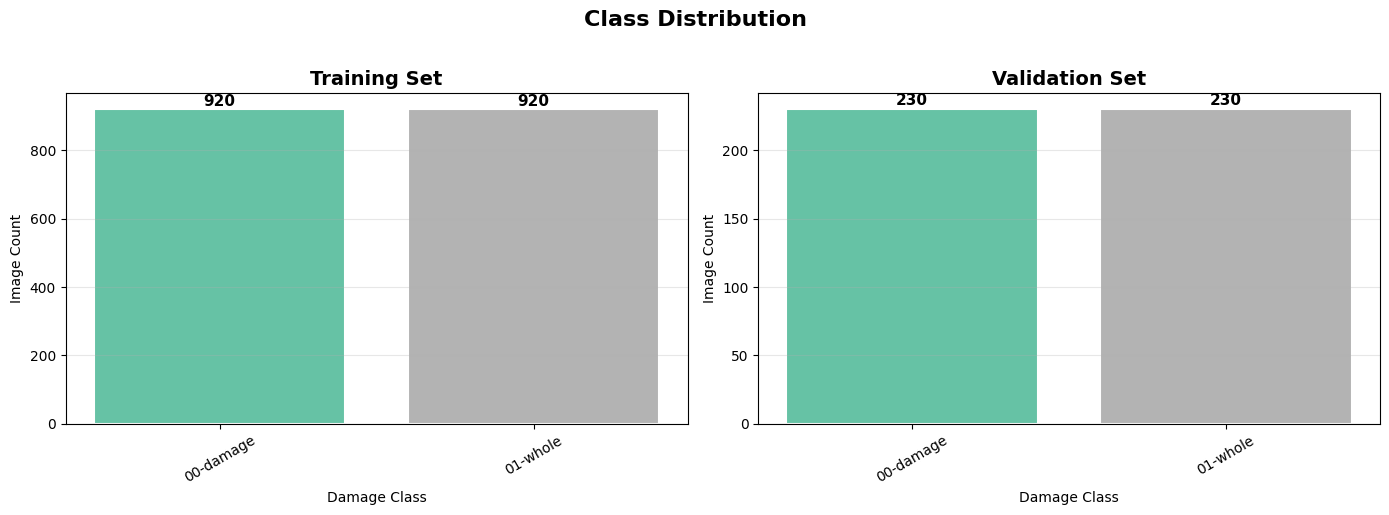

In [ ]:
# ── Visualise class distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))

for ax, (counts, title) in zip(axes,
    [(train_counts, 'Training Set'), (val_counts, 'Validation Set')]):
    bars = ax.bar(counts.keys(), counts.values(), color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Damage Class'); ax.set_ylabel('Image Count')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5, str(int(bar.get_height())),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Class Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

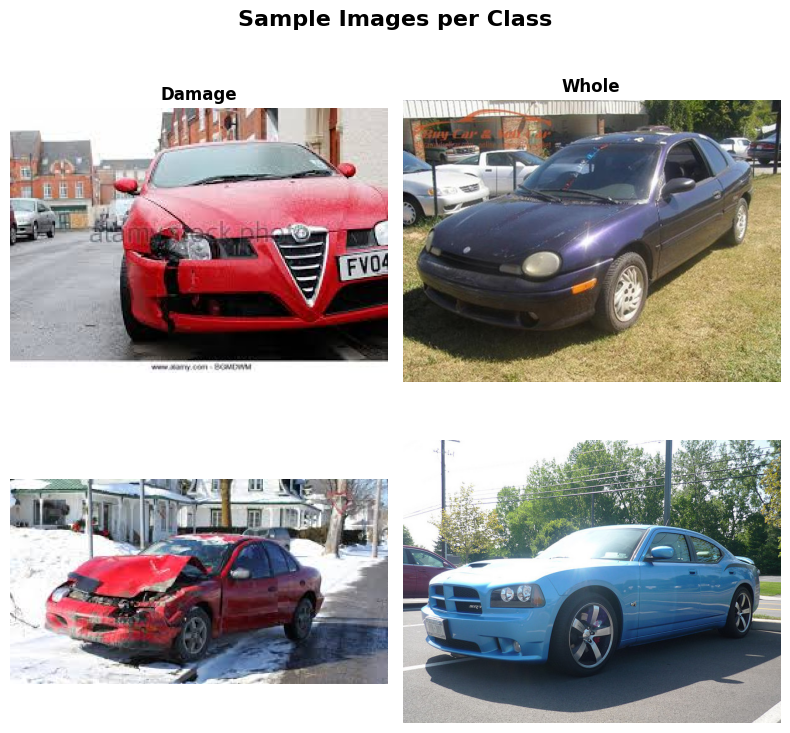

In [ ]:
# ── Sample images grid ───────────────────────────────────────
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(4*NUM_CLASSES, 8))

for col, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs = [f for f in os.listdir(cls_path)
            if os.path.splitext(f)[1].lower() in IMG_EXTENSIONS][:2]
    for row, img_file in enumerate(imgs[:2]):
        img = Image.open(os.path.join(cls_path, img_file)).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if row == 0:
            label = cls.split('-', 1)[-1].replace('-', ' ').title()
            axes[row][col].set_title(label, fontsize=12, fontweight='bold')

plt.suptitle('Sample Images per Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚙️ Step 3 — Data Pipeline with Augmentation

In [ ]:
# ── Hyper-parameters ─────────────────────────────────────────
IMG_SIZE    = (224, 224)   # ResNet50 standard
BATCH_SIZE  = 32
EPOCHS_FT   = 20           # Phase 1: frozen base
EPOCHS_UF   = 10           # Phase 2: unfreeze top layers
LR_FT       = 1e-3         # Phase 1 learning rate
LR_UF       = 1e-5         # Phase 2 fine-tune rate
DROPOUT     = 0.4
DENSE_UNITS = 256
UNFREEZE_FROM = 'conv5_block1_1_conv'  # unfreeze from this layer onward

print('Configuration:')
print(f'  Image size   : {IMG_SIZE}')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Classes      : {NUM_CLASSES}')
print(f'  Phase-1 LR   : {LR_FT}')
print(f'  Phase-2 LR   : {LR_UF}')

Configuration:
  Image size   : (224, 224)
  Batch size   : 32
  Classes      : 2
  Phase-1 LR   : 0.001
  Phase-2 LR   : 1e-05


In [ ]:
# ── tf.data pipeline ─────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

# Augmentation layers (applied only during training)
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
], name='augmentation')


def build_dataset(directory, augment=False, shuffle=True):
    """
    Build a tf.data.Dataset from an image folder.
    Returns (dataset, class_names).
    """
    ds = keras.utils.image_dataset_from_directory(
        directory,
        labels         = 'inferred',
        label_mode     = 'categorical',   # one-hot vectors
        class_names    = CLASS_NAMES,
        image_size     = IMG_SIZE,
        batch_size     = BATCH_SIZE,
        shuffle        = shuffle,
        seed           = SEED,
    )

    # Apply ResNet50 preprocessing (scales pixels to [-1, 1])
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)

    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)

    return ds.cache().prefetch(AUTOTUNE)


train_ds = build_dataset(TRAIN_DIR, augment=True,  shuffle=True)
val_ds   = build_dataset(VAL_DIR,   augment=False, shuffle=False)

print(f'Train batches : {len(train_ds)}')
print(f'Val   batches : {len(val_ds)}')

Found 1840 files belonging to 2 classes.
Found 460 files belonging to 2 classes.
Train batches : 58
Val   batches : 15


## 🧠 Step 4 — Build ResNet50 Model

In [ ]:
# ── Build model ──────────────────────────────────────────────
def build_model(num_classes, dropout=DROPOUT, dense_units=DENSE_UNITS):
    """
    ResNet50 backbone + custom classification head.

    Architecture:
        Input (224, 224, 3)
        → ResNet50 (frozen)
        → GlobalAveragePooling2D
        → BatchNorm → Dense(256, relu) → Dropout
        → Dense(num_classes, softmax)
    """
    # Load ImageNet weights, exclude top classification layers
    base = ResNet50(
        weights     = 'imagenet',
        include_top = False,
        input_shape = (*IMG_SIZE, 3)
    )
    base.trainable = False   # freeze all base layers initially

    # Custom head
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = base.output
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(dense_units, activation='relu', name='fc1')(x)
    x = layers.Dropout(dropout, name='dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = Model(inputs=base.input, outputs=outputs, name='CarDamageNet')
    return model, base


model, base_model = build_model(NUM_CLASSES)

model.compile(
    optimizer = keras.optimizers.Adam(LR_FT),
    loss      = 'categorical_crossentropy',
    metrics   = [
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

model.summary()
print(f'\nTotal params    : {model.count_params():,}')
print(f'Trainable params: {sum(v.numpy().size for v in model.trainable_variables):,}')

Model: "CarDamageNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,120,962 (92.01 MB)

 Trainable params: 529,154 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)


Total params    : 24,120,962
Trainable params: 529,154


## 🏋️ Step 5 — Phase 1: Train Classification Head

In [ ]:
# ── Callbacks ────────────────────────────────────────────────
os.makedirs('/content/models', exist_ok=True)

callbacks_phase1 = [
    EarlyStopping(
        monitor   = 'val_accuracy',
        patience  = 5,
        restore_best_weights = True,
        verbose   = 1
    ),
    ModelCheckpoint(
        '/content/models/best_phase1.keras',
        monitor   = 'val_accuracy',
        save_best_only = True,
        verbose   = 1
    ),
    ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.5,
        patience  = 3,
        min_lr    = 1e-7,
        verbose   = 1
    ),
]

print('Phase 1: Training classification head (base frozen)...')
history1 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS_FT,
    callbacks       = callbacks_phase1,
    verbose         = 1
)

Phase 1: Training classification head (base frozen)...
Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.6905 - loss: 0.8636 - precision: 0.6905 - recall: 0.6905
Epoch 1: val_accuracy improved from None to 0.84565, saving model to /content/models/best_phase1.keras

Epoch 1: finished saving model to /content/models/best_phase1.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 28s 297ms/step - accuracy: 0.7549 - loss: 0.7528 - precision: 0.7549 - recall: 0.7549 - val_accuracy: 0.8457 - val_loss: 0.3282 - val_precision: 0.8457 - val_recall: 0.8457 - learning_rate: 0.0010
Epoch 2/20
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8844 - loss: 0.2836 - precision: 0.8844 - recall: 0.8844
Epoch 2: val_accuracy improved from 0.84565 to 0.85652, saving model to /content/models/best_phase1.keras

Epoch 2: finished saving model to /content/models/best_phase1.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.8967 - loss: 0.2650 - precision: 0.8967 - recall: 0.8967 - val_accuracy: 0

## 🔓 Step 6 — Phase 2: Fine-Tune Top ResNet Layers

In [ ]:
# ── Unfreeze top ResNet layers ───────────────────────────────
# Find the layer index to unfreeze from
unfreeze_idx = None
for i, layer in enumerate(base_model.layers):
    if layer.name == UNFREEZE_FROM:
        unfreeze_idx = i
        break

if unfreeze_idx is None:
    # Fallback: unfreeze last 30 layers
    unfreeze_idx = len(base_model.layers) - 30

base_model.trainable = True
for layer in base_model.layers[:unfreeze_idx]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Unfroze layers from index {unfreeze_idx} ({trainable_count} trainable base layers)')

# Recompile with low LR for fine-tuning
model.compile(
    optimizer = keras.optimizers.Adam(LR_UF),
    loss      = 'categorical_crossentropy',
    metrics   = [
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

callbacks_phase2 = [
    EarlyStopping(
        monitor  = 'val_accuracy',
        patience = 5,
        restore_best_weights = True,
        verbose  = 1
    ),
    ModelCheckpoint(
        '/content/models/best_final.keras',
        monitor  = 'val_accuracy',
        save_best_only = True,
        verbose  = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-8,
        verbose  = 1
    ),
]

print('\nPhase 2: Fine-tuning top ResNet layers...')
history2 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS_UF,
    callbacks       = callbacks_phase2,
    verbose         = 1
)

Unfroze layers from index 143 (32 trainable base layers)

Phase 2: Fine-tuning top ResNet layers...
Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.9474 - loss: 0.1341 - precision: 0.9474 - recall: 0.9474
Epoch 1: val_accuracy improved from None to 0.88696, saving model to /content/models/best_final.keras

Epoch 1: finished saving model to /content/models/best_final.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 45s 415ms/step - accuracy: 0.9543 - loss: 0.1117 - precision: 0.9543 - recall: 0.9543 - val_accuracy: 0.8870 - val_loss: 0.3284 - val_precision: 0.8870 - val_recall: 0.8870 - learning_rate: 1.0000e-05
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9943 - loss: 0.0257 - precision: 0.9943 - recall: 0.9943
Epoch 2: val_accuracy did not improve from 0.88696
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.9940 - loss: 0.0288 - precision: 0.9940 - recall: 0.9940 - val_accuracy: 0.8717 - val_loss: 0.3832 - val_precision: 0.8717 - val_recall: 0.8717 - lear

## 📈 Step 7 — Training History Plots

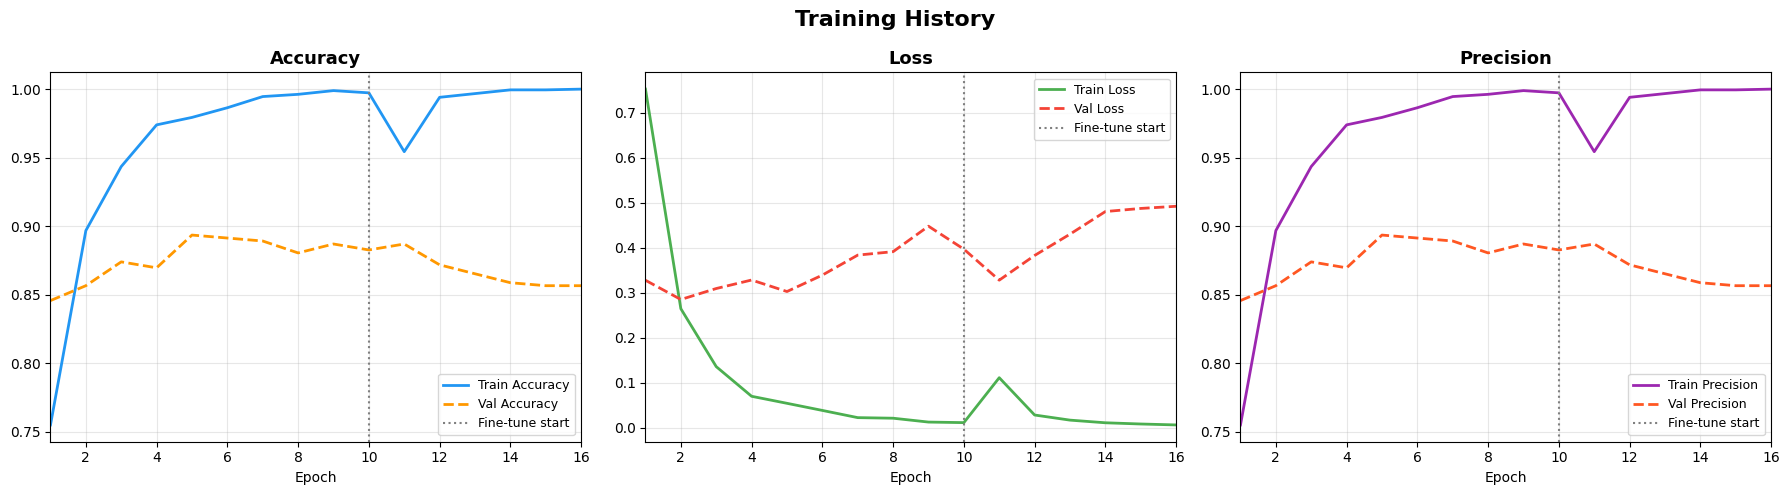

In [ ]:
# ── Merge both histories ─────────────────────────────────────
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history.get(key, [])
    return merged

hist = merge_histories(history1, history2)
phase1_end = len(history1.history['accuracy'])

def plot_history(hist, phase1_end):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Training History', fontsize=16, fontweight='bold')

    metrics = [
        ('accuracy',  'val_accuracy',  'Accuracy',  '#2196F3', '#FF9800'),
        ('loss',      'val_loss',      'Loss',      '#4CAF50', '#F44336'),
        ('precision', 'val_precision', 'Precision', '#9C27B0', '#FF5722'),
    ]

    epochs = range(1, len(hist['accuracy']) + 1)

    for ax, (tr_key, val_key, title, c1, c2) in zip(axes, metrics):
        if tr_key not in hist:
            ax.set_visible(False)
            continue
        ax.plot(epochs, hist[tr_key],  color=c1, linewidth=2, label=f'Train {title}')
        ax.plot(epochs, hist[val_key], color=c2, linewidth=2, linestyle='--',
                label=f'Val {title}')
        ax.axvline(x=phase1_end, color='gray', linestyle=':', linewidth=1.5,
                   label='Fine-tune start')
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        ax.set_xlim(1, len(epochs))

    plt.tight_layout()
    plt.savefig('/content/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(hist, phase1_end)

## 📊 Step 8 — Evaluation: Confusion Matrix & Classification Report

In [ ]:
# ── Collect predictions on validation set ────────────────────
print('Running inference on validation set...')

y_true, y_pred_probs = [], []

for images, labels in tqdm(val_ds, desc='Evaluating'):
    preds = model(images, training=False).numpy()
    y_pred_probs.append(preds)
    y_true.append(labels.numpy())

y_true_labels  = np.argmax(np.concatenate(y_true, axis=0), axis=1)
y_pred_labels  = np.argmax(np.concatenate(y_pred_probs, axis=0), axis=1)
y_pred_conf    = np.max(np.concatenate(y_pred_probs, axis=0), axis=1)

# Short class names for display
SHORT_NAMES = [c.split('-', 1)[-1].replace('-', ' ').title() for c in CLASS_NAMES]

print(f'Total samples evaluated: {len(y_true_labels)}')
print(f'Overall accuracy       : {(y_true_labels == y_pred_labels).mean():.4f}')

Running inference on validation set...


Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]

Total samples evaluated: 460
Overall accuracy       : 0.8870


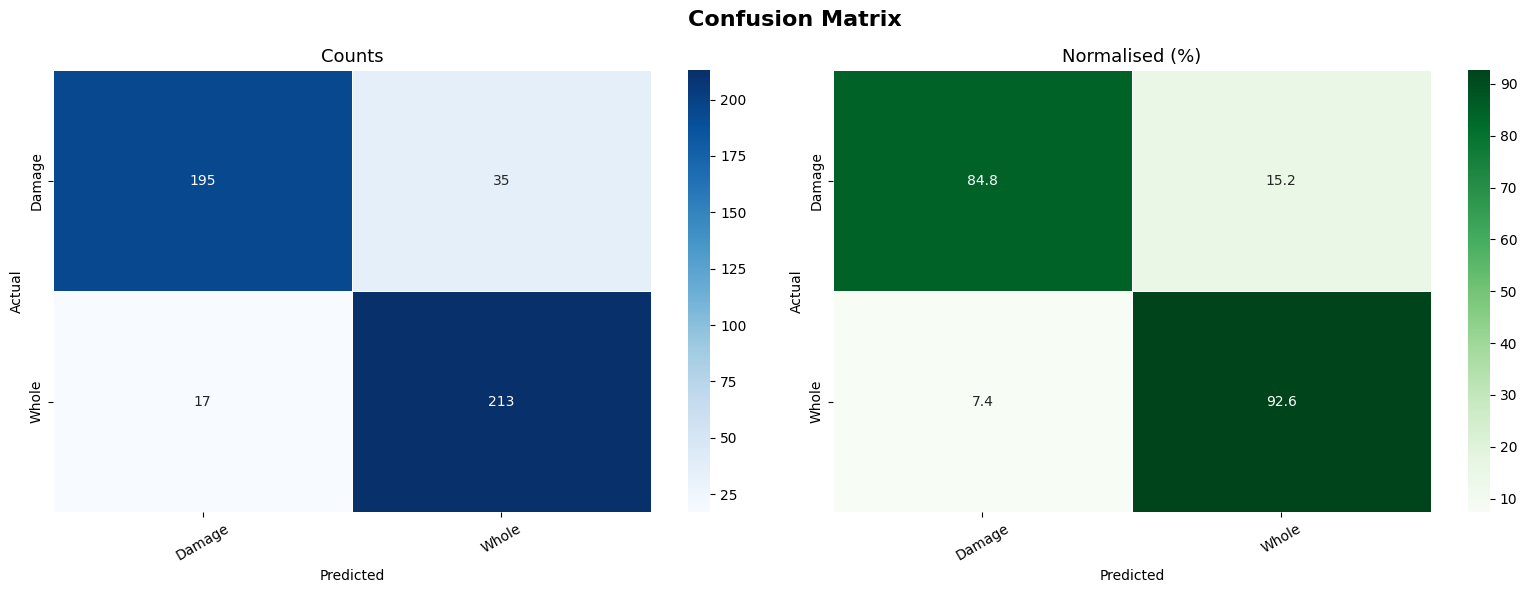

In [ ]:
# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_true_labels, y_pred_labels)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix', fontsize=16, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Counts', fontsize=13)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=30)

# Normalised %
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Normalised (%)', fontsize=13)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Classification Report ────────────────────────────────────
report = classification_report(
    y_true_labels, y_pred_labels,
    target_names = SHORT_NAMES,
    digits       = 4
)
print('\n' + '='*60)
print('         CLASSIFICATION REPORT')
print('='*60)
print(report)

# Save to file
with open('/content/classification_report.txt', 'w') as f:
    f.write(report)


         CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Damage     0.9198    0.8478    0.8824       230
       Whole     0.8589    0.9261    0.8912       230

    accuracy                         0.8870       460
   macro avg     0.8893    0.8870    0.8868       460
weighted avg     0.8893    0.8870    0.8868       460



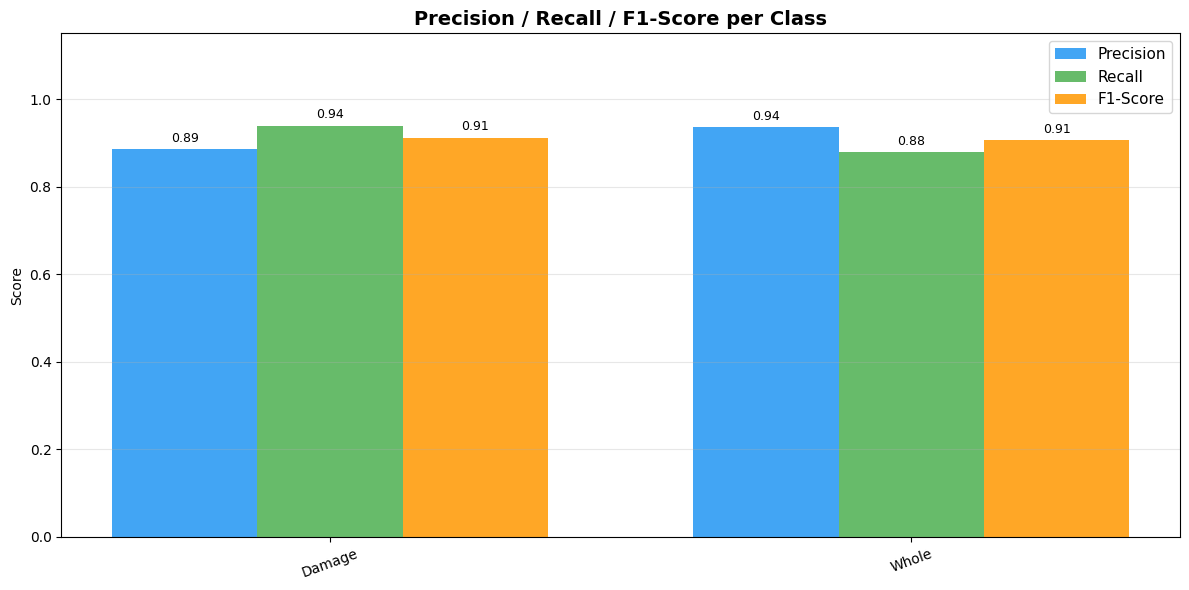


Macro Precision : 0.9102
Macro Recall    : 0.9087
Macro F1-Score  : 0.9086


In [ ]:
# ── Per-class bar chart: Precision / Recall / F1 ─────────────
precision, recall, f1, support = precision_recall_fscore_support(
    y_true_labels, y_pred_labels, average=None
)

x      = np.arange(NUM_CLASSES)
width  = 0.25
colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - width, precision, width, label='Precision', color=colors[0], alpha=0.85)
b2 = ax.bar(x,         recall,    width, label='Recall',    color=colors[1], alpha=0.85)
b3 = ax.bar(x + width, f1,        width, label='F1-Score',  color=colors[2], alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(SHORT_NAMES, rotation=20)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score'); ax.set_title('Precision / Recall / F1-Score per Class',
                                      fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/metrics_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

# Macro averages
print(f'\nMacro Precision : {precision.mean():.4f}')
print(f'Macro Recall    : {recall.mean():.4f}')
print(f'Macro F1-Score  : {f1.mean():.4f}')

## 🌡️ Step 9 — Grad-CAM: Prediction + Heatmap Overlay

In [ ]:
import tensorflow as tf
import numpy as np
import cv2

# ResNet50's last conv layer name (produces 7×7 feature maps)
LAST_CONV_LAYER = 'conv5_block3_out'

# def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
#     """
#     Compute Grad-CAM heatmap for the top predicted class.

#     img_array : preprocessed image batch, shape (1, H, W, 3)
#     Returns   : heatmap np.ndarray (h, w) normalised to [0, 1]
#     """

#     # 1. Get the last convolutional layer's output from the base model
#     last_conv_layer_output = model.get_layer('resnet50').get_layer(last_conv_layer_name).output

#     # 2. Reconstruct the path for the final predictions from the base model's output
#     # This ensures a consistent graph even after model fine-tuning.
#     x = model.get_layer('resnet50').output # Output of the resnet50 layer itself
#     x = model.get_layer('gap')(x)
#     x = model.get_layer('batch_normalization')(x)
#     x = model.get_layer('fc1')(x)
#     x = model.get_layer('dropout')(x)
#     final_predictions_output = model.get_layer('predictions')(x)

#     # Create a new Functional model that takes the original inputs
#     # and outputs both the last conv layer's output and the final predictions.
#     grad_model = tf.keras.models.Model(
#         inputs  = model.inputs,
#         outputs = [
#             last_conv_layer_output,
#             final_predictions_output
#         ]
#     )

#     with tf.GradientTape() as tape:
#         inputs = tf.cast(img_array, tf.float32)
#         conv_outputs, predictions = grad_model(inputs)
#         top_class_idx = tf.argmax(predictions[0])
#         top_class_score = predictions[:, top_class_idx]

#     # Gradient of top-class score w.r.t. conv feature maps
#     grads = tape.gradient(top_class_score, conv_outputs)       # (1, h, w, C)
#     pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))       # (C,)

#     # Weighted combination of feature maps
#     conv_outputs = conv_outputs[0]                              # (h, w, C)
#     heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]     # (h, w, 1)
#     heatmap = tf.squeeze(heatmap)                              # (h, w)

#     # ReLU + normalise
#     heatmap = tf.nn.relu(heatmap)
#     heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
#     return heatmap.numpy(), int(top_class_idx.numpy()), predictions.numpy()[0]

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # Extract base model (ResNet50)
    base_model = model.get_layer(last_conv_layer_name)

    # Create a model that maps input → last conv layer
    last_conv_layer = model.get_layer(last_conv_layer_name)

    # Build a new model from SAME input → conv + final output
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            last_conv_layer.output,   # from base model
            model.output             # final prediction
        ]
    )

    # 🔥 CRITICAL FIX: Force model build (prevents KeyError)
    _ = grad_model(img_array)

    with tf.GradientTape() as tape:
        inputs = tf.cast(img_array, tf.float32)

        conv_outputs, predictions = grad_model(inputs, training=False)

        top_class_idx = tf.argmax(predictions[0])
        top_class_score = predictions[:, top_class_idx]

    grads = tape.gradient(top_class_score, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), int(top_class_idx.numpy()), predictions.numpy()[0]

def overlay_gradcam(original_img_rgb, heatmap, alpha=0.45):
    """
    Blend JET-coloured heatmap onto the original image.

    original_img_rgb : uint8 (H, W, 3)
    heatmap          : float (h, w) in [0, 1]
    Returns          : uint8 (H, W, 3) blended image
    """
    H, W = original_img_rgb.shape[:2]
    heatmap_uint8 = np.uint8(255 * heatmap)
    # Apply JET colormap
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    # Resize to original image size
    heatmap_resized = cv2.resize(heatmap_color, (W, H))
    # Alpha blend
    blended = cv2.addWeighted(original_img_rgb, 1 - alpha,
                               heatmap_resized,    alpha, 0)
    return blended


print('Grad-CAM functions ready \u2713')


Grad-CAM functions ready ✓


In [ ]:
model.summary()

Model: "CarDamageNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 55,131,272 (210.31 MB)

 Trainable params: 15,505,154 (59.15 MB)

 Non-trainable params: 8,615,808 (32.87 MB)

 Optimizer params: 31,010,310 (118.29 MB)

In [ ]:
# ── Predict + Grad-CAM on random val images ──────────────────
def predict_and_visualise(image_path, model, true_label=None, save_path=None):
    """
    Load an image, run prediction, generate Grad-CAM overlay, and display
    a side-by-side figure: Original | Grad-CAM | Confidence bar chart.

    Returns: (predicted_class_name, confidence_score)
    """
    # ── Load & preprocess ────────────────────────────────────
    original = np.array(Image.open(image_path).convert('RGB').resize(IMG_SIZE))
    preprocessed = preprocess_input(original.astype(np.float32))
    img_batch = np.expand_dims(preprocessed, axis=0)   # (1, 224, 224, 3)

    # ── Grad-CAM ─────────────────────────────────────────────
    heatmap, pred_idx, probs = make_gradcam_heatmap(img_batch, model, LAST_CONV_LAYER)
    overlay = overlay_gradcam(original, heatmap)

    pred_class   = CLASS_NAMES[pred_idx]
    pred_label   = SHORT_NAMES[pred_idx]
    confidence   = float(probs[pred_idx]) * 100

    # ── Figure ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Panel 1 – Original
    axes[0].imshow(original)
    axes[0].set_title('Original Image', fontsize=13, fontweight='bold')
    axes[0].axis('off')
    if true_label:
        axes[0].set_xlabel(f'True: {true_label}', fontsize=11, color='#555')

    # Panel 2 – Grad-CAM overlay
    axes[1].imshow(overlay)
    correct = (true_label is None) or (pred_label.lower() in true_label.lower())
    title_color = '#1B5E20' if correct else '#B71C1C'
    axes[1].set_title(
        f'Grad-CAM Heatmap\nPredicted: {pred_label} ({confidence:.1f}%)',
        fontsize=12, fontweight='bold', color=title_color
    )
    axes[1].axis('off')

    # Colorbar for heatmap scale
    sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0, 1))
    plt.colorbar(sm, ax=axes[1], orientation='vertical',
                 fraction=0.04, pad=0.02, label='Activation')

    # Panel 3 – Confidence bar chart
    bar_colors = ['#E53935' if i == pred_idx else '#90CAF9' for i in range(NUM_CLASSES)]
    bars = axes[2].barh(SHORT_NAMES, probs * 100, color=bar_colors, edgecolor='white')
    axes[2].set_xlim(0, 115)
    axes[2].set_xlabel('Confidence (%)')
    axes[2].set_title('Class Probabilities', fontsize=13, fontweight='bold')
    axes[2].grid(axis='x', alpha=0.3)
    for bar, prob in zip(bars, probs):
        axes[2].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{prob*100:.1f}%', va='center', fontsize=10)

    plt.suptitle('Car Damage Detection — Prediction', fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()

    return pred_label, confidence


print('predict_and_visualise() ready ✓')

predict_and_visualise() ready ✓


In [ ]:
for layer in model.layers:
    if "conv5" in layer.name:
        print(layer.name)

conv5_block1_1_conv
conv5_block1_1_bn
conv5_block1_1_relu
conv5_block1_2_conv
conv5_block1_2_bn
conv5_block1_2_relu
conv5_block1_0_conv
conv5_block1_3_conv
conv5_block1_0_bn
conv5_block1_3_bn
conv5_block1_add
conv5_block1_out
conv5_block2_1_conv
conv5_block2_1_bn
conv5_block2_1_relu
conv5_block2_2_conv
conv5_block2_2_bn
conv5_block2_2_relu
conv5_block2_3_conv
conv5_block2_3_bn
conv5_block2_add
conv5_block2_out
conv5_block3_1_conv
conv5_block3_1_bn
conv5_block3_1_relu
conv5_block3_2_conv
conv5_block3_2_bn
conv5_block3_2_relu
conv5_block3_3_conv
conv5_block3_3_bn
conv5_block3_add
conv5_block3_out


Running Grad-CAM predictions on sample images...

Saved → /content/gradcam_00-damage.png


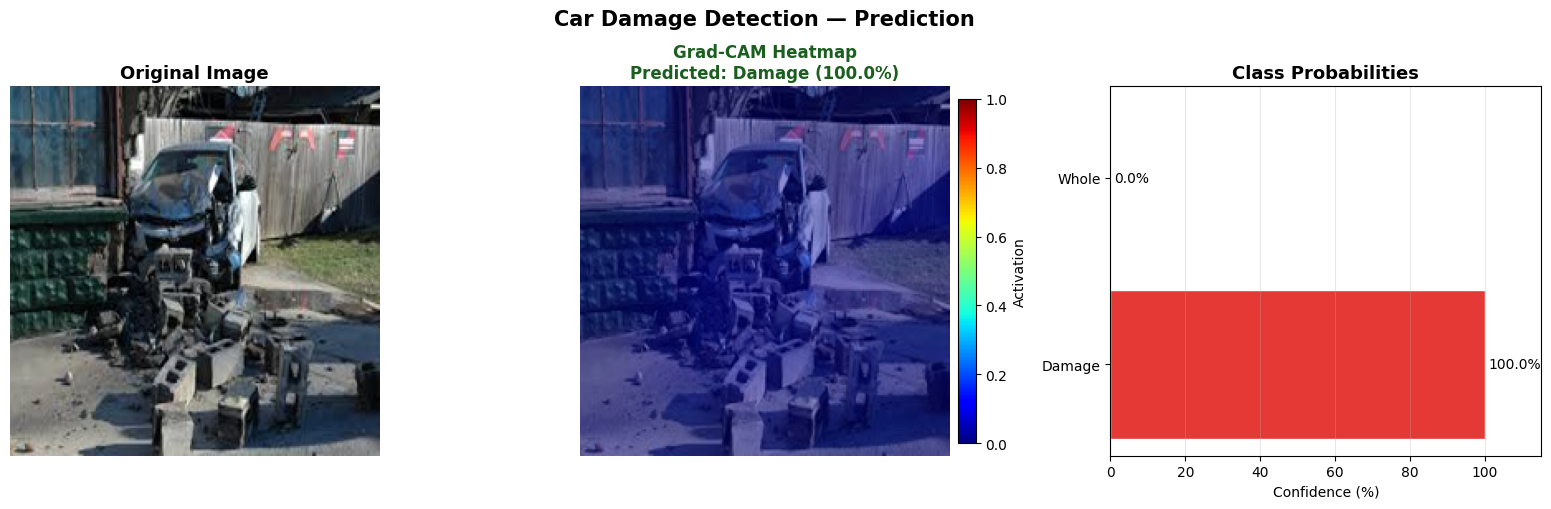

  Class: Damage                Predicted: Damage                Confidence: 100.0%

Saved → /content/gradcam_01-whole.png


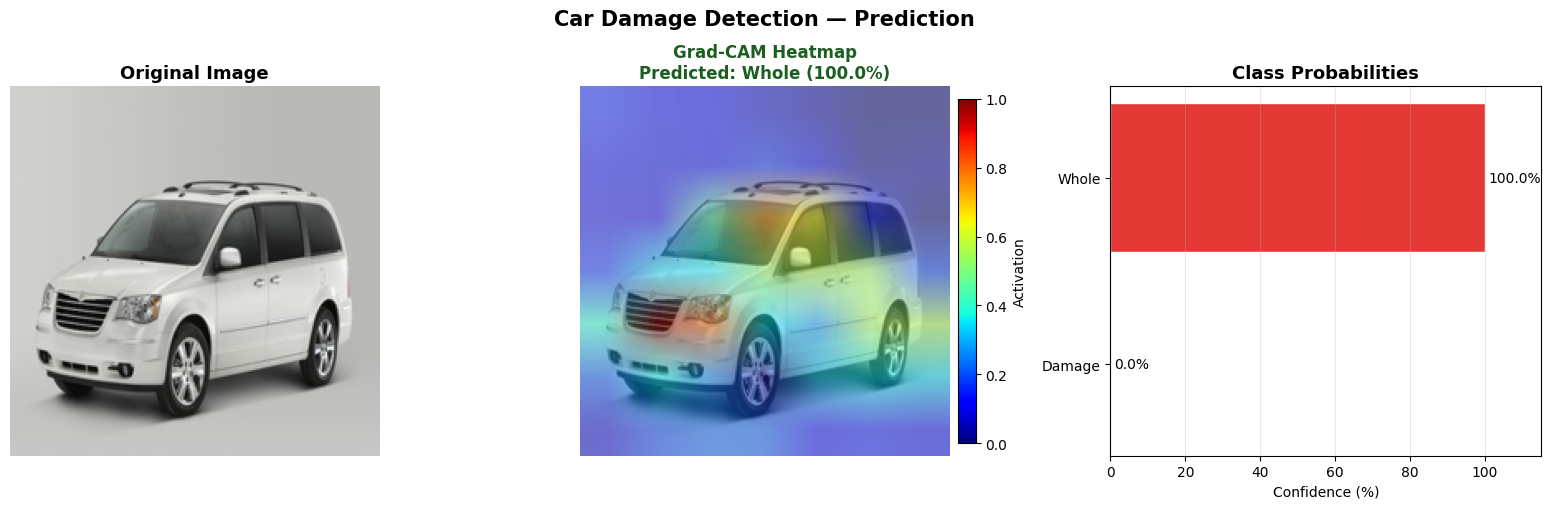

  Class: Whole                 Predicted: Whole                 Confidence: 100.0%



In [ ]:
# ── Run on one sample per class ──────────────────────────────
print('Running Grad-CAM predictions on sample images...\n')

for cls in CLASS_NAMES:
    cls_dir = os.path.join(VAL_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
    imgs = [f for f in os.listdir(cls_dir)
            if os.path.splitext(f)[1].lower() in IMG_EXTENSIONS]
    if not imgs:
        continue

    sample = os.path.join(cls_dir, random.choice(imgs))
    true_label = cls.split('-', 1)[-1].replace('-', ' ').title()
    save_path  = f'/content/gradcam_{cls}.png'

    pred_label, conf = predict_and_visualise(
        sample, model,
        true_label = true_label,
        save_path  = save_path
    )
    print(f'  Class: {true_label:<20}  Predicted: {pred_label:<20}  Confidence: {conf:.1f}%\n')

## 🖼️ Step 10 — Predict on Your Own Image

Upload a car damage image (jpg/png):


Saving sample.jpg to sample.jpg

→ Processing: sample.jpg
Saved → /content/prediction_sample.jpg


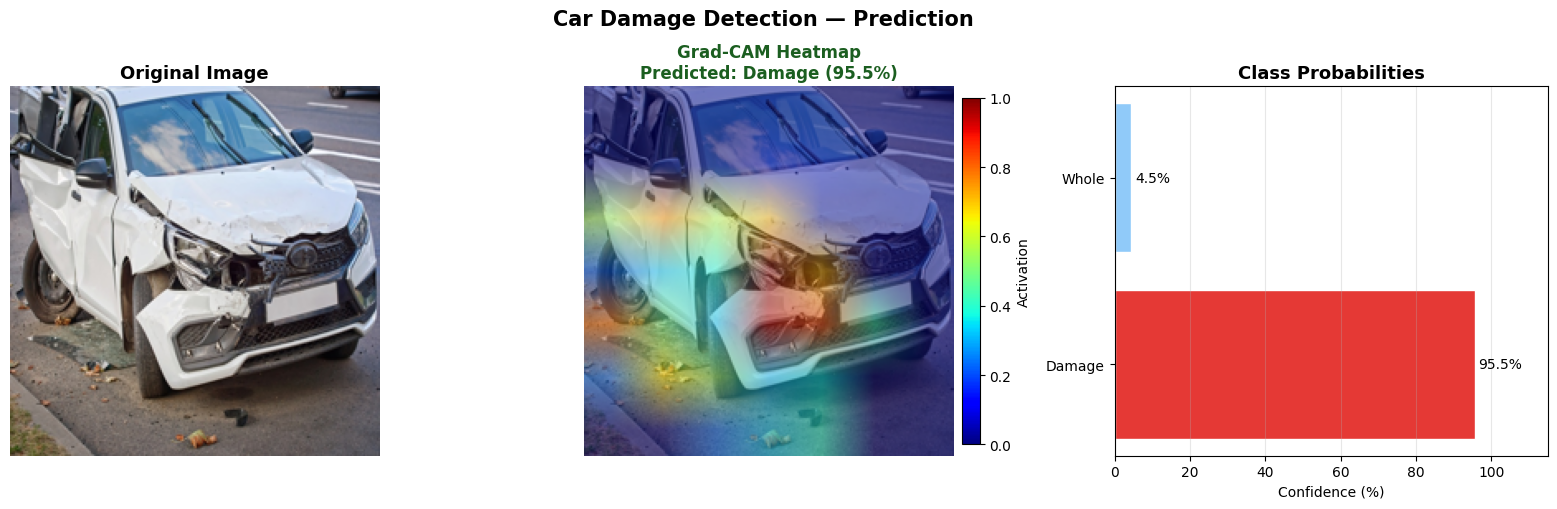


✅  Predicted Damage Type : Damage
   Confidence            : 95.54%


In [ ]:
# ── Upload any car image and get a prediction ─────────────────
from google.colab import files

print('Upload a car damage image (jpg/png):')
uploaded_files = files.upload()

for fname in uploaded_files:
    print(f'\n→ Processing: {fname}')
    pred_label, conf = predict_and_visualise(
        fname, model,
        save_path = f'/content/prediction_{fname}'
    )
    print(f'\n✅  Predicted Damage Type : {pred_label}')
    print(f'   Confidence            : {conf:.2f}%')

## 💾 Step 11 — Save Model & Download Results

In [ ]:
# ── Save final model ─────────────────────────────────────────
model.save('/content/models/car_damage_model_final.keras')
print('Model saved to /content/models/car_damage_model_final.keras')

# ── Zip everything ───────────────────────────────────────────
import zipfile

OUTPUT_FILES = [
    '/content/training_history.png',
    '/content/confusion_matrix.png',
    '/content/metrics_per_class.png',
    '/content/class_distribution.png',
    '/content/sample_images.png',
    '/content/classification_report.txt',
    '/content/models/car_damage_model_final.keras',
    '/content/models/best_final.keras',
]

# Add Grad-CAM images
for cls in CLASS_NAMES:
    p = f'/content/gradcam_{cls}.png'
    if os.path.exists(p):
        OUTPUT_FILES.append(p)

zip_path = '/content/car_damage_detection_results.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    for f in OUTPUT_FILES:
        if os.path.exists(f):
            zf.write(f, os.path.basename(f))
            print(f'  Added: {os.path.basename(f)}')

print(f'\n✅  Results zipped → {zip_path}')

# Download
from google.colab import files
files.download(zip_path)

Model saved to /content/models/car_damage_model_final.keras
  Added: training_history.png
  Added: confusion_matrix.png
  Added: metrics_per_class.png
  Added: class_distribution.png
  Added: sample_images.png
  Added: classification_report.txt
  Added: car_damage_model_final.keras
  Added: best_final.keras
  Added: gradcam_00-damage.png
  Added: gradcam_01-whole.png

✅  Results zipped → /content/car_damage_detection_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ✅ Summary

| Component | Detail |
|---|---|
| **Model** | ResNet50 (ImageNet pretrained) + custom head |
| **Training** | Phase 1: frozen base → Phase 2: top layers unfrozen |
| **Augmentation** | Flip, Rotation, Zoom, Brightness, Contrast |
| **Loss** | Categorical Cross-Entropy |
| **Optimizer** | Adam (1e-3 → 1e-5) |
| **Callbacks** | EarlyStopping, ReduceLROnPlateau, ModelCheckpoint |
| **Metrics** | Accuracy, Precision, Recall, F1-Score |
| **Explainability** | Grad-CAM heatmap overlay |